# 🌿 FarmAI Cameroun — Notebook 1 : Pipeline Vision
## Détection de maladies de la tomate avec EfficientNet-B0
**Challenge ACIAI 2026 | ENSPY — Génie Informatique**

Ce notebook couvre :
1. Chargement et extraction du dataset PlantVillage (ZIP)
2. Prétraitement et augmentation des données
3. Transfer Learning avec EfficientNet-B0
4. Entraînement, évaluation et visualisation
5. Export en TFLite quantisé (INT8) pour déploiement mobile

## 0. Installation des dépendances

In [ ]:
import subprocess, sys

subprocess.check_call([
    sys.executable, '-m', 'pip', 'install',
    '--quiet', '--force-reinstall',
    'numpy==1.26.4', 'pandas==2.2.2', 'seaborn==0.13.2'
])

# Forcer le rechargement complet
import importlib, os
os.kill(os.getpid(), 9)  # Tue et redémarre le kernel automatiquement

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.7/12.7 MB 104.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 510.5/510.5 kB 36.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 349.3/349.3 kB 28.5 MB/s eta 0:00:00


ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
bigframes 2.35.0 requires google-cloud-bigquery-storage<3.0.0,>=2.30.0, which is not installed.
google-adk 1.25.1 requires google-cloud-bigquery-storage>=2.0.0, which is not installed.
kaggle-environments 1.27.3 requires numpy>=2.0, but you have numpy 1.26.4 which is incompatible.
ydata-profiling 4.18.1 requires matplotlib<=3.10,>=3.5, but you have matplotlib 3.10.9 which is incompatible.
cesium 0.12.4 requires numpy<3.0,>=2.0, but you have numpy 1.26.4 which is incompatible.
google-colab 1.0.0 requires jupyter-server==2.14.0, but you have jupyter-server 2.12.5 which is incompatible.
dopamine-rl 4.1.2 requires gym<=0.25.2, but you have gym 0.26.2 which is incompatible.
jaxlib 0.7.2 requires numpy>=2.0, but you have numpy 1.26.4 which is incompatible.
cupy-cuda12x 14.0.1 requires numpy<2.6,>=2.0, but you have numpy

In [1]:
!pip install -q "numpy<2.0" pandas seaborn --force-reinstall 2>/dev/null

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.0/61.0 kB 3.0 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 79.5/79.5 kB 7.3 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 52.8/52.8 kB 4.1 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 117.5/117.5 kB 10.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.0/18.0 MB 86.4 MB/s eta 0:00:00:00:010:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.9/10.9 MB 115.9 MB/s eta 0:00:0000:010:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 294.9/294.9 kB 25.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.8/8.8 MB 97.1 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 229.9/229.9 kB 19.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 362.6/362.6 kB 28.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.0/5.0 MB 108.4 MB/s eta 0:00:0000:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 70.8 MB/s eta 0:00:00
   ━━━━━━━

In [1]:
!pip install -q tensorflow-model-optimization 2>/dev/null

## 1. Imports et configuration

In [2]:
import os
import shutil
import random
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, callbacks
from tensorflow.keras.applications import EfficientNetB0

from sklearn.metrics import classification_report, confusion_matrix
# Reproductibilité
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

# Configuration
IMG_SIZE    = 224
BATCH_SIZE  = 32
EPOCHS_HEAD = 10
EPOCHS_FINE = 20
LR_HEAD     = 1e-3
LR_FINE     = 1e-5

# Chemin racine PlantVillage sur Kaggle (déjà extrait)
PLANTVILLAGE_ROOT = '/kaggle/input/datasets/arjuntejaswi/plant-village/PlantVillage'

# Dossiers tomate uniquement (on exclut Pepper et Potato)
FOLDER_MAP = {
    'Tomato_Bacterial_spot'                        : 'Bacterial_spot',
    'Tomato_Early_blight'                          : 'Early_blight',
    'Tomato_healthy'                               : 'healthy',
    'Tomato_Late_blight'                           : 'Late_blight',
    'Tomato_Leaf_Mold'                             : 'Leaf_Mold',
    'Tomato_Septoria_leaf_spot'                    : 'Septoria_leaf_spot',
    'Tomato_Spider_mites_Two_spotted_spider_mite'  : 'Spider_mites',
    'Tomato__Target_Spot'                          : 'Target_Spot',
    'Tomato__Tomato_mosaic_virus'                  : 'Tomato_mosaic_virus',
    'Tomato__Tomato_YellowLeaf__Curl_Virus'        : 'YellowLeaf_Curl_Virus',
}

CLASS_NAMES = list(FOLDER_MAP.values())
NUM_CLASSES = len(CLASS_NAMES)

# Dossiers de travail (dans /kaggle/working pour éviter de copier sur l'input read-only)
DATA_DIR  = '/kaggle/working/farmai_tomato'
TRAIN_DIR = os.path.join(DATA_DIR, 'train')
VAL_DIR   = os.path.join(DATA_DIR, 'val')
TEST_DIR  = os.path.join(DATA_DIR, 'test')

print(f'✅ TensorFlow version : {tf.__version__}')
print(f'✅ GPU disponible     : {tf.config.list_physical_devices("GPU")}')
print(f'✅ Nombre de classes  : {NUM_CLASSES}')
print(f'✅ Classes            : {CLASS_NAMES}')

# Vérification que les dossiers tomate existent bien
print('\n🔍 Vérification des dossiers source :')
for src_name in FOLDER_MAP:
    path = os.path.join(PLANTVILLAGE_ROOT, src_name)
    status = '✅' if os.path.exists(path) else '❌ MANQUANT'
    n = len(os.listdir(path)) if os.path.exists(path) else 0
    print(f'  {status}  {src_name:<55} ({n} images)')

2026-05-02 17:34:21.367410: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1777743261.548973     146 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1777743261.600175     146 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1777743262.018234     146 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1777743262.018270     146 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1777743262.018272     146 computation_placer.cc:177] computation placer alr

✅ TensorFlow version : 2.19.0
✅ GPU disponible     : [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU'), PhysicalDevice(name='/physical_device:GPU:1', device_type='GPU')]
✅ Nombre de classes  : 10
✅ Classes            : ['Bacterial_spot', 'Early_blight', 'healthy', 'Late_blight', 'Leaf_Mold', 'Septoria_leaf_spot', 'Spider_mites', 'Target_Spot', 'Tomato_mosaic_virus', 'YellowLeaf_Curl_Virus']

🔍 Vérification des dossiers source :
  ✅  Tomato_Bacterial_spot                                   (2127 images)
  ✅  Tomato_Early_blight                                     (1000 images)
  ✅  Tomato_healthy                                          (1591 images)
  ✅  Tomato_Late_blight                                      (1909 images)
  ✅  Tomato_Leaf_Mold                                        (952 images)
  ✅  Tomato_Septoria_leaf_spot                               (1771 images)
  ✅  Tomato_Spider_mites_Two_spotted_spider_mite             (1676 images)
  ✅  Tomato__Target_Spot    

## 2. Chargement et extraction du dataset PlantVillage

In [5]:
# Chemin direct vers PlantVillage (déjà disponible sur Kaggle, pas de ZIP)
PLANTVILLAGE_ROOT = '/kaggle/input/datasets/arjuntejaswi/plant-village/PlantVillage'

DATA_DIR  = '/kaggle/working/farmai_tomato'
TRAIN_DIR = os.path.join(DATA_DIR, 'train')
VAL_DIR   = os.path.join(DATA_DIR, 'val')
TEST_DIR  = os.path.join(DATA_DIR, 'test')

FOLDER_MAP = {
    'Tomato_Bacterial_spot'                       : 'Bacterial_spot',
    'Tomato_Early_blight'                         : 'Early_blight',
    'Tomato_healthy'                              : 'healthy',
    'Tomato_Late_blight'                          : 'Late_blight',
    'Tomato_Leaf_Mold'                            : 'Leaf_Mold',
    'Tomato_Septoria_leaf_spot'                   : 'Septoria_leaf_spot',
    'Tomato_Spider_mites_Two_spotted_spider_mite' : 'Spider_mites',
    'Tomato__Target_Spot'                         : 'Target_Spot',
    'Tomato__Tomato_mosaic_virus'                 : 'Tomato_mosaic_virus',
    'Tomato__Tomato_YellowLeaf__Curl_Virus'       : 'YellowLeaf_Curl_Virus'
}

def split_dataset(plantvillage_root, data_dir, folder_map,
                  train_ratio=0.70, val_ratio=0.15, seed=42):
    """
    Lit directement depuis le dossier Kaggle (read-only),
    copie uniquement les classes tomate dans train/val/test.
    """
    random.seed(seed)

    # Vérification que le dossier source existe
    if not os.path.exists(plantvillage_root):
        raise FileNotFoundError(
            f'Dossier PlantVillage introuvable : {plantvillage_root}\n'
            f'Vérifie le nom exact dans /kaggle/input/'
        )

    stats = {}
    for src_name, dst_name in folder_map.items():
        src = os.path.join(plantvillage_root, src_name)

        if not os.path.exists(src):
            print(f'⚠️  Dossier manquant : {src_name}')
            continue

        images = [f for f in os.listdir(src)
                  if f.lower().endswith(('.jpg', '.jpeg', '.png'))]
        random.shuffle(images)

        n       = len(images)
        n_train = int(n * train_ratio)
        n_val   = int(n * val_ratio)

        splits = {
            'train': images[:n_train],
            'val'  : images[n_train:n_train + n_val],
            'test' : images[n_train + n_val:]
        }

        for split, imgs in splits.items():
            dst_dir = os.path.join(data_dir, split, dst_name)
            os.makedirs(dst_dir, exist_ok=True)
            for img in imgs:
                shutil.copy(os.path.join(src, img),
                            os.path.join(dst_dir, img))

        stats[dst_name] = {
            'total': n,
            'train': n_train,
            'val'  : n_val,
            'test' : n - n_train - n_val
        }
        print(f'✅ {dst_name:<30} {n:>6} images copiées')

    return stats


# Vérification si le split existe déjà (évite de recopier à chaque run)
if os.path.exists(TRAIN_DIR):
    print('✅ Split déjà effectué, on passe directement à l\'entraînement.')
    stats = {}
    for dst_name in FOLDER_MAP.values():
        for split, d in [('train', TRAIN_DIR), ('val', VAL_DIR), ('test', TEST_DIR)]:
            path = os.path.join(d, dst_name)
            n = len(os.listdir(path)) if os.path.exists(path) else 0
            if dst_name not in stats:
                stats[dst_name] = {'train': 0, 'val': 0, 'test': 0, 'total': 0}
            stats[dst_name][split] = n
            stats[dst_name]['total'] += n
else:
    print('📂 Création du split train/val/test...')
    stats = split_dataset(PLANTVILLAGE_ROOT, DATA_DIR, FOLDER_MAP)

# Affichage des statistiques
print(f'\n{"Classe":<30} {"Total":>7} {"Train":>7} {"Val":>6} {"Test":>6}')
print('-' * 60)
total_all = 0
for cls, s in stats.items():
    print(f'{cls:<30} {s["total"]:>7} {s["train"]:>7} {s["val"]:>6} {s["test"]:>6}')
    total_all += s['total']
print('-' * 60)
print(f'{"TOTAL":<30} {total_all:>7}')

📂 Création du split train/val/test...
✅ Bacterial_spot                   2127 images copiées
✅ Early_blight                     1000 images copiées
✅ healthy                          1591 images copiées
✅ Late_blight                      1909 images copiées
✅ Leaf_Mold                         952 images copiées
✅ Septoria_leaf_spot               1771 images copiées
✅ Spider_mites                     1676 images copiées
✅ Target_Spot                      1404 images copiées
✅ Tomato_mosaic_virus               373 images copiées
✅ YellowLeaf_Curl_Virus            3208 images copiées

Classe                           Total   Train    Val   Test
------------------------------------------------------------
Bacterial_spot                    2127    1488    319    320
Early_blight                      1000     700    150    150
healthy                           1591    1113    238    240
Late_blight                       1909    1336    286    287
Leaf_Mold                          952     66

## 3. Pipelines de données avec augmentation

I0000 00:00:1777743461.580318     146 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13757 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1777743461.586103     146 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13757 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


Found 11203 files belonging to 10 classes.
Found 2397 files belonging to 10 classes.
Found 2411 files belonging to 10 classes.
✅ Train batches : 351
✅ Val   batches : 75
✅ Test  batches : 76


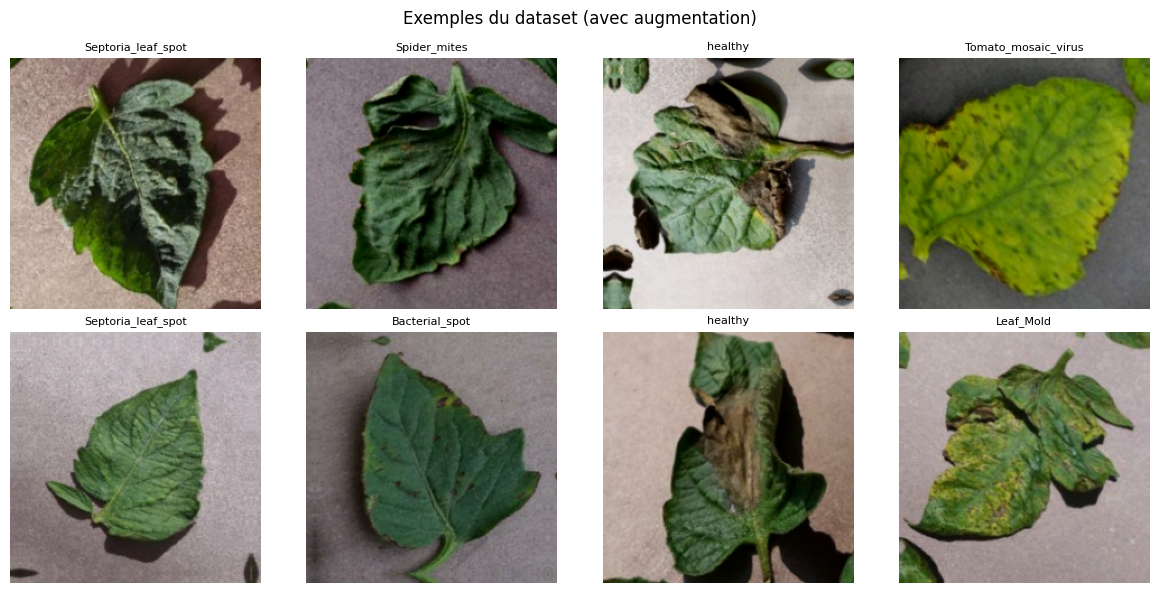

In [6]:
# Couche d'augmentation (appliquée uniquement en entraînement)
data_augmentation = keras.Sequential([
    layers.RandomFlip('horizontal_and_vertical'),
    layers.RandomRotation(0.2),
    layers.RandomZoom(0.15),
    layers.RandomBrightness(0.1),
    layers.RandomContrast(0.1),
], name='augmentation')

def preprocess(image, label):
    """Normalisation EfficientNet : pixels [0, 255] → rescale interne."""
    image = tf.cast(image, tf.float32)
    # EfficientNetB0 inclut son propre rescaling, on passe les pixels bruts
    return image, label

def make_dataset(directory, training=False):
    ds = keras.utils.image_dataset_from_directory(
        directory,
        image_size=(IMG_SIZE, IMG_SIZE),
        batch_size=BATCH_SIZE,
        label_mode='categorical',
        shuffle=training,
        seed=SEED
    )
    ds = ds.map(preprocess, num_parallel_calls=tf.data.AUTOTUNE)
    if training:
        ds = ds.map(lambda x, y: (data_augmentation(x, training=True), y),
                    num_parallel_calls=tf.data.AUTOTUNE)
    return ds.prefetch(tf.data.AUTOTUNE)


train_ds = make_dataset(TRAIN_DIR, training=True)
val_ds   = make_dataset(VAL_DIR,   training=False)
test_ds  = make_dataset(TEST_DIR,  training=False)

print(f'✅ Train batches : {len(train_ds)}')
print(f'✅ Val   batches : {len(val_ds)}')
print(f'✅ Test  batches : {len(test_ds)}')

# Visualisation d'un batch avec augmentation
plt.figure(figsize=(12, 6))
for images, labels in train_ds.take(1):
    for i in range(min(8, BATCH_SIZE)):
        ax = plt.subplot(2, 4, i + 1)
        plt.imshow(images[i].numpy().astype('uint8'))
        plt.title(CLASS_NAMES[np.argmax(labels[i])], fontsize=8)
        plt.axis('off')
plt.suptitle('Exemples du dataset (avec augmentation)', fontsize=12)
plt.tight_layout()
plt.show()

## 4. Construction du modèle — Transfer Learning EfficientNet-B0

In [7]:
def build_model(num_classes, trainable_base=False):
    """
    EfficientNetB0 pré-entraîné ImageNet.
    Phase 1 : base gelée, on entraîne seulement la tête.
    Phase 2 : fine-tuning des dernières couches.
    """
    base = EfficientNetB0(
        include_top=False,
        weights='imagenet',
        input_shape=(IMG_SIZE, IMG_SIZE, 3)
    )
    base.trainable = trainable_base

    inputs  = keras.Input(shape=(IMG_SIZE, IMG_SIZE, 3))
    x       = base(inputs, training=False)
    x       = layers.GlobalAveragePooling2D()(x)
    x       = layers.BatchNormalization()(x)
    x       = layers.Dropout(0.3)(x)
    x       = layers.Dense(256, activation='relu',
                            kernel_regularizer=keras.regularizers.l2(1e-4))(x)
    x       = layers.Dropout(0.2)(x)
    outputs = layers.Dense(num_classes, activation='softmax')(x)

    model = keras.Model(inputs, outputs)
    return model, base


model, base_model = build_model(NUM_CLASSES, trainable_base=False)

model.compile(
    optimizer=keras.optimizers.Adam(LR_HEAD),
    loss='categorical_crossentropy',
    metrics=['accuracy', keras.metrics.TopKCategoricalAccuracy(k=3, name='top3_acc')]
)

model.summary()
print(f'\n✅ Paramètres entraînables (Phase 1) : {model.trainable_variables.__len__()}')

16705208/16705208 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_2 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ efficientnetb0 (Functional)     │ (None, 7, 7, 1280)     │     4,049,571 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 1280)           │         5,120 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │       327,936 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,385,197 (16.73 MB)

 Trainable params: 333,066 (1.27 MB)

 Non-trainable params: 4,052,131 (15.46 MB)


✅ Paramètres entraînables (Phase 1) : 6


## 5. Phase 1 — Entraînement de la tête de classification

In [9]:
# Callbacks
cb_early   = callbacks.EarlyStopping(monitor='val_accuracy', patience=5,
                                      restore_best_weights=True, verbose=1)
cb_reduce  = callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.5,
                                          patience=3, min_lr=1e-7, verbose=1)
cb_ckpt    = callbacks.ModelCheckpoint('/kaggle/working/farmai_phase1_best.h5',
                                        monitor='val_accuracy', save_best_only=True,
                                        verbose=1)

print('🚀 Phase 1 : Entraînement de la tête (base gelée)...')
history1 = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS_HEAD,
    callbacks=[cb_early, cb_reduce, cb_ckpt],
    verbose=1
)

val_acc_phase1 = max(history1.history['val_accuracy'])
print(f'\n✅ Meilleure val_accuracy Phase 1 : {val_acc_phase1:.4f}')

🚀 Phase 1 : Entraînement de la tête (base gelée)...
Epoch 1/10
350/351 ━━━━━━━━━━━━━━━━━━━━ 0s 162ms/step - accuracy: 0.9163 - loss: 0.3148 - top3_acc: 0.9946
Epoch 1: val_accuracy improved from -inf to 0.92616, saving model to /kaggle/working/farmai_phase1_best.h5


351/351 ━━━━━━━━━━━━━━━━━━━━ 61s 171ms/step - accuracy: 0.9163 - loss: 0.3148 - top3_acc: 0.9946 - val_accuracy: 0.9262 - val_loss: 0.3024 - val_top3_acc: 0.9929 - learning_rate: 5.0000e-04
Epoch 2/10
351/351 ━━━━━━━━━━━━━━━━━━━━ 0s 162ms/step - accuracy: 0.9241 - loss: 0.3002 - top3_acc: 0.9932
Epoch 2: val_accuracy improved from 0.92616 to 0.93450, saving model to /kaggle/working/farmai_phase1_best.h5


351/351 ━━━━━━━━━━━━━━━━━━━━ 61s 171ms/step - accuracy: 0.9241 - loss: 0.3002 - top3_acc: 0.9932 - val_accuracy: 0.9345 - val_loss: 0.2809 - val_top3_acc: 0.9937 - learning_rate: 5.0000e-04
Epoch 3/10
350/351 ━━━━━━━━━━━━━━━━━━━━ 0s 164ms/step - accuracy: 0.9255 - loss: 0.2969 - top3_acc: 0.9928
Epoch 3: val_accuracy improved from 0.93450 to 0.93617, saving model to /kaggle/working/farmai_phase1_best.h5


351/351 ━━━━━━━━━━━━━━━━━━━━ 61s 173ms/step - accuracy: 0.9255 - loss: 0.2969 - top3_acc: 0.9928 - val_accuracy: 0.9362 - val_loss: 0.2776 - val_top3_acc: 0.9950 - learning_rate: 5.0000e-04
Epoch 4/10
350/351 ━━━━━━━━━━━━━━━━━━━━ 0s 163ms/step - accuracy: 0.9245 - loss: 0.3011 - top3_acc: 0.9938
Epoch 4: val_accuracy did not improve from 0.93617
351/351 ━━━━━━━━━━━━━━━━━━━━ 60s 170ms/step - accuracy: 0.9245 - loss: 0.3011 - top3_acc: 0.9938 - val_accuracy: 0.9287 - val_loss: 0.2957 - val_top3_acc: 0.9929 - learning_rate: 5.0000e-04
Epoch 5/10
351/351 ━━━━━━━━━━━━━━━━━━━━ 0s 162ms/step - accuracy: 0.9273 - loss: 0.2897 - top3_acc: 0.9945
Epoch 5: val_accuracy did not improve from 0.93617
351/351 ━━━━━━━━━━━━━━━━━━━━ 60s 170ms/step - accuracy: 0.9273 - loss: 0.2897 - top3_acc: 0.9945 - val_accuracy: 0.9262 - val_loss: 0.3042 - val_top3_acc: 0.9925 - learning_rate: 5.0000e-04
Epoch 6/10
351/351 ━━━━━━━━━━━━━━━━━━━━ 0s 161ms/step - accuracy: 0.9269 - loss: 0.2847 - top3_acc: 0.9943
Epoch 6

351/351 ━━━━━━━━━━━━━━━━━━━━ 60s 170ms/step - accuracy: 0.9269 - loss: 0.2847 - top3_acc: 0.9943 - val_accuracy: 0.9408 - val_loss: 0.2671 - val_top3_acc: 0.9950 - learning_rate: 5.0000e-04
Epoch 7/10
351/351 ━━━━━━━━━━━━━━━━━━━━ 0s 162ms/step - accuracy: 0.9287 - loss: 0.2843 - top3_acc: 0.9961
Epoch 7: val_accuracy improved from 0.94076 to 0.94326, saving model to /kaggle/working/farmai_phase1_best.h5


351/351 ━━━━━━━━━━━━━━━━━━━━ 61s 171ms/step - accuracy: 0.9287 - loss: 0.2843 - top3_acc: 0.9961 - val_accuracy: 0.9433 - val_loss: 0.2566 - val_top3_acc: 0.9950 - learning_rate: 5.0000e-04
Epoch 8/10
351/351 ━━━━━━━━━━━━━━━━━━━━ 0s 162ms/step - accuracy: 0.9301 - loss: 0.2776 - top3_acc: 0.9939
Epoch 8: val_accuracy did not improve from 0.94326
351/351 ━━━━━━━━━━━━━━━━━━━━ 60s 170ms/step - accuracy: 0.9301 - loss: 0.2776 - top3_acc: 0.9939 - val_accuracy: 0.9374 - val_loss: 0.2688 - val_top3_acc: 0.9954 - learning_rate: 5.0000e-04
Epoch 9/10
351/351 ━━━━━━━━━━━━━━━━━━━━ 0s 162ms/step - accuracy: 0.9309 - loss: 0.2792 - top3_acc: 0.9933
Epoch 9: val_accuracy did not improve from 0.94326
351/351 ━━━━━━━━━━━━━━━━━━━━ 60s 170ms/step - accuracy: 0.9309 - loss: 0.2792 - top3_acc: 0.9933 - val_accuracy: 0.9328 - val_loss: 0.2800 - val_top3_acc: 0.9950 - learning_rate: 5.0000e-04
Epoch 10/10
350/351 ━━━━━━━━━━━━━━━━━━━━ 0s 163ms/step - accuracy: 0.9315 - loss: 0.2829 - top3_acc: 0.9938
Epoch 

## 6. Phase 2 — Fine-tuning des dernières couches

In [12]:
# Dégeler les 30 dernières couches de la base
base_model.trainable = True
FINE_TUNE_AT = len(base_model.layers) - 30
for layer in base_model.layers[:FINE_TUNE_AT]:
    layer.trainable = False

n_trainable = sum(1 for l in base_model.layers if l.trainable)
print(f'✅ Couches dégelées dans la base : {n_trainable}')

model.compile(
    optimizer=keras.optimizers.Adam(LR_FINE),
    loss='categorical_crossentropy',
    metrics=['accuracy', keras.metrics.TopKCategoricalAccuracy(k=3, name='top3_acc')]
)

cb_ckpt2 = callbacks.ModelCheckpoint('/kaggle/working/farmai_phase2_best.h5',
                                       monitor='val_accuracy', save_best_only=True,
                                       verbose=1)
cb_csv   = callbacks.CSVLogger('/kaggle/working/training_log.csv')

print('🚀 Phase 2 : Fine-tuning...')
history2 = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS_FINE,
    callbacks=[cb_early, cb_reduce, cb_ckpt2, cb_csv],
    verbose=1
)

val_acc_phase2 = max(history2.history['val_accuracy'])
print(f'\n✅ Meilleure val_accuracy Phase 2 : {val_acc_phase2:.4f}')

✅ Couches dégelées dans la base : 30
🚀 Phase 2 : Fine-tuning...
Epoch 1/20
351/351 ━━━━━━━━━━━━━━━━━━━━ 0s 195ms/step - accuracy: 0.9485 - loss: 0.2397 - top3_acc: 0.9964
Epoch 1: val_accuracy improved from -inf to 0.95411, saving model to /kaggle/working/farmai_phase2_best.h5


351/351 ━━━━━━━━━━━━━━━━━━━━ 110s 236ms/step - accuracy: 0.9485 - loss: 0.2397 - top3_acc: 0.9964 - val_accuracy: 0.9541 - val_loss: 0.2153 - val_top3_acc: 0.9967 - learning_rate: 1.0000e-05
Epoch 2/20
351/351 ━━━━━━━━━━━━━━━━━━━━ 0s 160ms/step - accuracy: 0.9452 - loss: 0.2390 - top3_acc: 0.9966
Epoch 2: val_accuracy improved from 0.95411 to 0.95453, saving model to /kaggle/working/farmai_phase2_best.h5


351/351 ━━━━━━━━━━━━━━━━━━━━ 60s 169ms/step - accuracy: 0.9452 - loss: 0.2390 - top3_acc: 0.9966 - val_accuracy: 0.9545 - val_loss: 0.2131 - val_top3_acc: 0.9962 - learning_rate: 1.0000e-05
Epoch 3/20
350/351 ━━━━━━━━━━━━━━━━━━━━ 0s 162ms/step - accuracy: 0.9499 - loss: 0.2280 - top3_acc: 0.9980
Epoch 3: val_accuracy improved from 0.95453 to 0.95620, saving model to /kaggle/working/farmai_phase2_best.h5


351/351 ━━━━━━━━━━━━━━━━━━━━ 61s 171ms/step - accuracy: 0.9499 - loss: 0.2280 - top3_acc: 0.9980 - val_accuracy: 0.9562 - val_loss: 0.2075 - val_top3_acc: 0.9971 - learning_rate: 1.0000e-05
Epoch 4/20
350/351 ━━━━━━━━━━━━━━━━━━━━ 0s 166ms/step - accuracy: 0.9509 - loss: 0.2246 - top3_acc: 0.9952
Epoch 4: val_accuracy did not improve from 0.95620
351/351 ━━━━━━━━━━━━━━━━━━━━ 61s 174ms/step - accuracy: 0.9509 - loss: 0.2246 - top3_acc: 0.9952 - val_accuracy: 0.9562 - val_loss: 0.2096 - val_top3_acc: 0.9971 - learning_rate: 1.0000e-05
Epoch 5/20
350/351 ━━━━━━━━━━━━━━━━━━━━ 0s 163ms/step - accuracy: 0.9508 - loss: 0.2327 - top3_acc: 0.9966
Epoch 5: val_accuracy did not improve from 0.95620
351/351 ━━━━━━━━━━━━━━━━━━━━ 60s 170ms/step - accuracy: 0.9507 - loss: 0.2327 - top3_acc: 0.9966 - val_accuracy: 0.9554 - val_loss: 0.2067 - val_top3_acc: 0.9967 - learning_rate: 1.0000e-05
Epoch 6/20
350/351 ━━━━━━━━━━━━━━━━━━━━ 0s 163ms/step - accuracy: 0.9513 - loss: 0.2239 - top3_acc: 0.9980
Epoch 6

351/351 ━━━━━━━━━━━━━━━━━━━━ 61s 172ms/step - accuracy: 0.9513 - loss: 0.2239 - top3_acc: 0.9980 - val_accuracy: 0.9579 - val_loss: 0.2051 - val_top3_acc: 0.9975 - learning_rate: 1.0000e-05
Epoch 7/20
350/351 ━━━━━━━━━━━━━━━━━━━━ 0s 163ms/step - accuracy: 0.9593 - loss: 0.2044 - top3_acc: 0.9973
Epoch 7: val_accuracy improved from 0.95786 to 0.95828, saving model to /kaggle/working/farmai_phase2_best.h5


...

351/351 ━━━━━━━━━━━━━━━━━━━━ 61s 173ms/step - accuracy: 0.9556 - loss: 0.2120 - top3_acc: 0.9974 - val_accuracy: 0.9599 - val_loss: 0.1922 - val_top3_acc: 0.9983 - learning_rate: 1.0000e-05
Epoch 11/20
350/351 ━━━━━━━━━━━━━━━━━━━━ 0s 161ms/step - accuracy: 0.9568 - loss: 0.2043 - top3_acc: 0.9974
Epoch 11: val_accuracy did not improve from 0.95995
351/351 ━━━━━━━━━━━━━━━━━━━━ 60s 169ms/step - accuracy: 0.9568 - loss: 0.2043 - top3_acc: 0.9974 - val_accuracy: 0.9591 - val_loss: 0.1926 - val_top3_acc: 0.9983 - learning_rate: 1.0000e-05
Epoch 12/20
350/351 ━━━━━━━━━━━━━━━━━━━━ 0s 166ms/step - accuracy: 0.9558 - loss: 0.2103 - top3_acc: 0.9982
Epoch 12: val_accuracy improved from 0.95995 to 0.96120, saving model to /kaggle/working/farmai_phase2_best.h5


351/351 ━━━━━━━━━━━━━━━━━━━━ 62s 175ms/step - accuracy: 0.9558 - loss: 0.2103 - top3_acc: 0.9982 - val_accuracy: 0.9612 - val_loss: 0.1855 - val_top3_acc: 0.9983 - learning_rate: 1.0000e-05
Epoch 13/20
350/351 ━━━━━━━━━━━━━━━━━━━━ 0s 163ms/step - accuracy: 0.9585 - loss: 0.2002 - top3_acc: 0.9975
Epoch 13: val_accuracy did not improve from 0.96120
351/351 ━━━━━━━━━━━━━━━━━━━━ 60s 171ms/step - accuracy: 0.9585 - loss: 0.2002 - top3_acc: 0.9975 - val_accuracy: 0.9608 - val_loss: 0.1866 - val_top3_acc: 0.9979 - learning_rate: 1.0000e-05
Epoch 14/20
351/351 ━━━━━━━━━━━━━━━━━━━━ 0s 164ms/step - accuracy: 0.9590 - loss: 0.2017 - top3_acc: 0.9966
Epoch 14: val_accuracy improved from 0.96120 to 0.96204, saving model to /kaggle/working/farmai_phase2_best.h5


351/351 ━━━━━━━━━━━━━━━━━━━━ 61s 173ms/step - accuracy: 0.9590 - loss: 0.2017 - top3_acc: 0.9966 - val_accuracy: 0.9620 - val_loss: 0.1848 - val_top3_acc: 0.9979 - learning_rate: 1.0000e-05
Epoch 15/20
350/351 ━━━━━━━━━━━━━━━━━━━━ 0s 165ms/step - accuracy: 0.9602 - loss: 0.1959 - top3_acc: 0.9983
Epoch 15: val_accuracy improved from 0.96204 to 0.96370, saving model to /kaggle/working/farmai_phase2_best.h5


351/351 ━━━━━━━━━━━━━━━━━━━━ 62s 174ms/step - accuracy: 0.9602 - loss: 0.1959 - top3_acc: 0.9983 - val_accuracy: 0.9637 - val_loss: 0.1866 - val_top3_acc: 0.9979 - learning_rate: 1.0000e-05
Epoch 16/20
350/351 ━━━━━━━━━━━━━━━━━━━━ 0s 164ms/step - accuracy: 0.9618 - loss: 0.1867 - top3_acc: 0.9980
Epoch 16: val_accuracy did not improve from 0.96370
351/351 ━━━━━━━━━━━━━━━━━━━━ 61s 172ms/step - accuracy: 0.9618 - loss: 0.1867 - top3_acc: 0.9980 - val_accuracy: 0.9625 - val_loss: 0.1872 - val_top3_acc: 0.9979 - learning_rate: 1.0000e-05
Epoch 17/20
350/351 ━━━━━━━━━━━━━━━━━━━━ 0s 163ms/step - accuracy: 0.9594 - loss: 0.2016 - top3_acc: 0.9972
Epoch 17: val_accuracy did not improve from 0.96370
351/351 ━━━━━━━━━━━━━━━━━━━━ 61s 171ms/step - accuracy: 0.9594 - loss: 0.2015 - top3_acc: 0.9972 - val_accuracy: 0.9633 - val_loss: 0.1811 - val_top3_acc: 0.9979 - learning_rate: 1.0000e-05
Epoch 18/20
351/351 ━━━━━━━━━━━━━━━━━━━━ 0s 161ms/step - accuracy: 0.9621 - loss: 0.1915 - top3_acc: 0.9983
Ep

351/351 ━━━━━━━━━━━━━━━━━━━━ 62s 174ms/step - accuracy: 0.9634 - loss: 0.1878 - top3_acc: 0.9974 - val_accuracy: 0.9658 - val_loss: 0.1805 - val_top3_acc: 0.9983 - learning_rate: 1.0000e-05
Epoch 20/20
350/351 ━━━━━━━━━━━━━━━━━━━━ 0s 163ms/step - accuracy: 0.9625 - loss: 0.1805 - top3_acc: 0.9985
Epoch 20: val_accuracy did not improve from 0.96579
351/351 ━━━━━━━━━━━━━━━━━━━━ 60s 170ms/step - accuracy: 0.9625 - loss: 0.1805 - top3_acc: 0.9985 - val_accuracy: 0.9645 - val_loss: 0.1778 - val_top3_acc: 0.9987 - learning_rate: 1.0000e-05
Restoring model weights from the end of the best epoch: 19.

✅ Meilleure val_accuracy Phase 2 : 0.9658


## 7. Courbes d'apprentissage

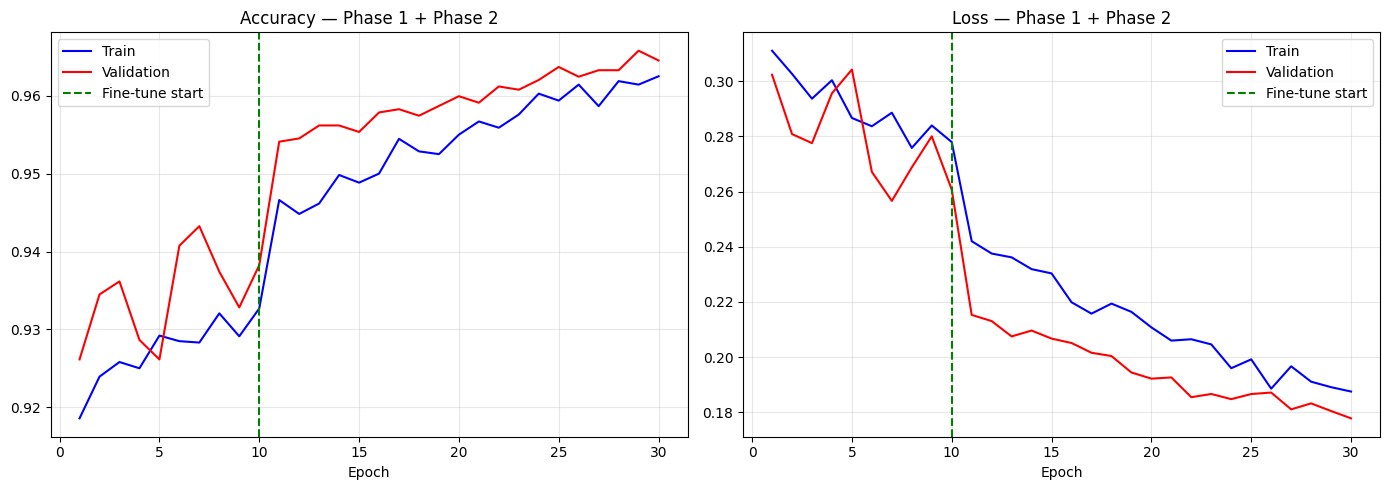

In [13]:
def plot_history(h1, h2):
    acc  = h1.history['accuracy']      + h2.history['accuracy']
    val  = h1.history['val_accuracy']  + h2.history['val_accuracy']
    loss = h1.history['loss']          + h2.history['loss']
    vloss= h1.history['val_loss']      + h2.history['val_loss']
    ep   = range(1, len(acc) + 1)
    cut  = len(h1.history['accuracy'])

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    for ax, train_m, val_m, title in zip(
        axes,
        [acc, loss], [val, vloss],
        ['Accuracy', 'Loss']
    ):
        ax.plot(ep, train_m, 'b-', label='Train')
        ax.plot(ep, val_m,   'r-', label='Validation')
        ax.axvline(x=cut, color='green', linestyle='--', label='Fine-tune start')
        ax.set_title(f'{title} — Phase 1 + Phase 2')
        ax.set_xlabel('Epoch')
        ax.legend()
        ax.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.savefig('/kaggle/working/farmai_training_curves.png', dpi=150)
    plt.show()

plot_history(history1, history2)

## 8. Évaluation sur le set de test

In [14]:
# Chargement du meilleur modèle
model.load_weights('/kaggle/working/farmai_phase2_best.h5')

# Évaluation globale
test_loss, test_acc, test_top3 = model.evaluate(test_ds, verbose=1)
print(f'\n📊 Test Accuracy  : {test_acc:.4f} ({test_acc*100:.2f}%)')
print(f'📊 Test Top-3 Acc : {test_top3:.4f} ({test_top3*100:.2f}%)')
print(f'📊 Test Loss      : {test_loss:.4f}')

# Prédictions pour rapport détaillé
y_true, y_pred = [], []
for images, labels in test_ds:
    preds = model.predict(images, verbose=0)
    y_true.extend(np.argmax(labels.numpy(), axis=1))
    y_pred.extend(np.argmax(preds, axis=1))

y_true = np.array(y_true)
y_pred = np.array(y_pred)

print('\n📋 Rapport de classification :')
print(classification_report(y_true, y_pred, target_names=CLASS_NAMES, digits=4))

74/76 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step - accuracy: 0.9569 - loss: 0.1993 - top3_acc: 0.9988

2026-05-02 18:46:21.683804: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-05-02 18:46:21.821815: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-05-02 18:46:22.137160: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-05-02 18:46:22.278596: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-05-02 18:46:23.053428: E external/local_xla/xla/stream_

76/76 ━━━━━━━━━━━━━━━━━━━━ 13s 166ms/step - accuracy: 0.9573 - loss: 0.1983 - top3_acc: 0.9988

📊 Test Accuracy  : 0.9660 (96.60%)
📊 Test Top-3 Acc : 0.9988 (99.88%)
📊 Test Loss      : 0.1733

📋 Rapport de classification :
                       precision    recall  f1-score   support

       Bacterial_spot     0.9904    0.9625    0.9762       320
         Early_blight     1.0000    0.8533    0.9209       150
              healthy     0.9530    0.9895    0.9709       287
          Late_blight     1.0000    0.9653    0.9823       144
            Leaf_Mold     0.9560    0.9775    0.9667       267
   Septoria_leaf_spot     0.9549    0.9246    0.9395       252
         Spider_mites     0.8904    0.9575    0.9227       212
          Target_Spot     1.0000    0.9474    0.9730        57
  Tomato_mosaic_virus     1.0000    0.9938    0.9969       482
YellowLeaf_Curl_Virus     0.9339    1.0000    0.9658       240

             accuracy                         0.9660      2411
            macro a

## 9. Matrice de confusion

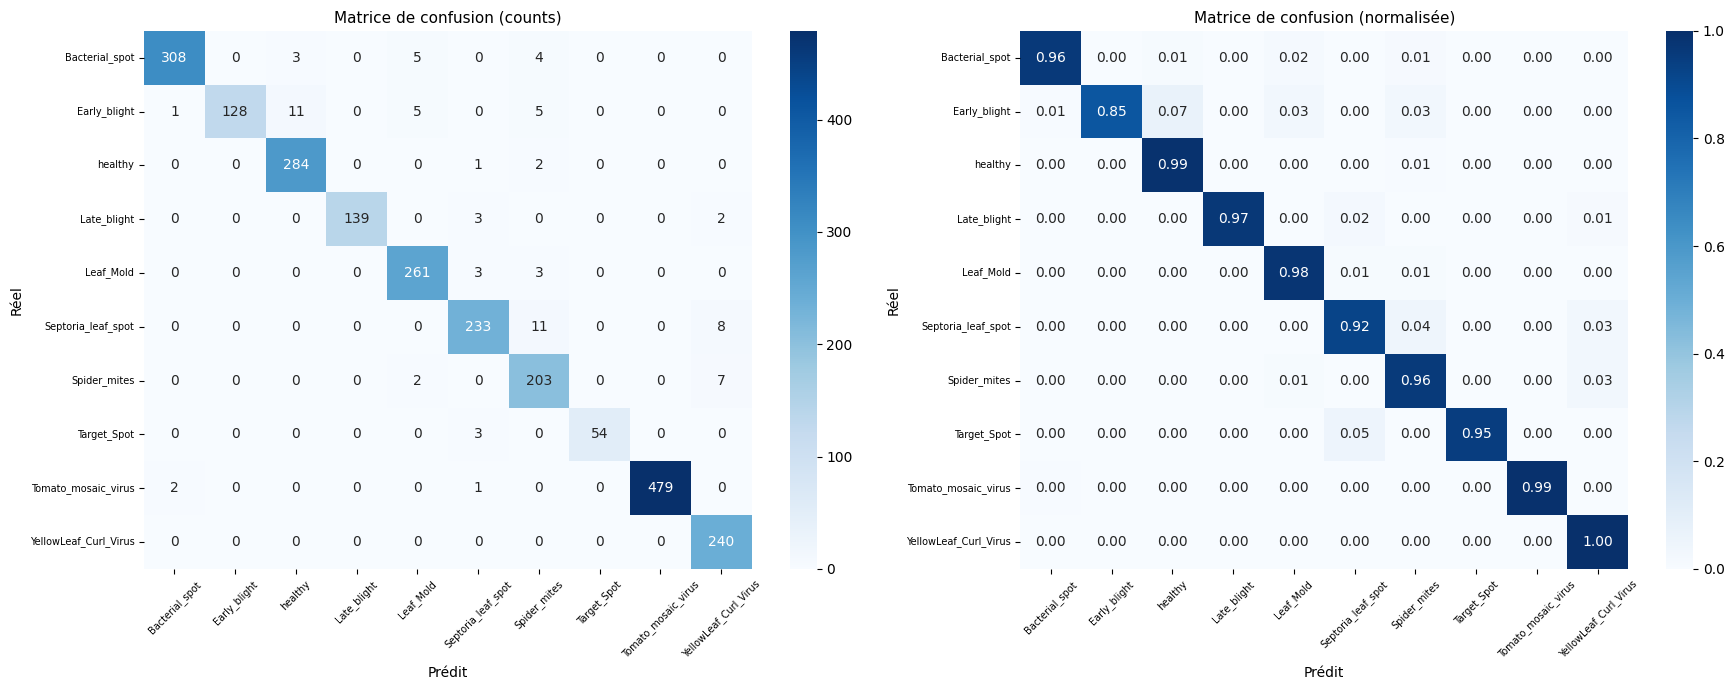

In [15]:
cm = confusion_matrix(y_true, y_pred)
cm_norm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]

fig, axes = plt.subplots(1, 2, figsize=(18, 7))

for ax, data, fmt, title in zip(
    axes,
    [cm, cm_norm], ['d', '.2f'],
    ['Matrice de confusion (counts)', 'Matrice de confusion (normalisée)']
):
    sns.heatmap(data, annot=True, fmt=fmt, cmap='Blues',
                xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES,
                ax=ax, cbar=True)
    ax.set_title(title, fontsize=11)
    ax.set_xlabel('Prédit')
    ax.set_ylabel('Réel')
    ax.tick_params(axis='x', rotation=45, labelsize=7)
    ax.tick_params(axis='y', rotation=0, labelsize=7)

plt.tight_layout()
plt.savefig('/kaggle/working/farmai_confusion_matrix.png', dpi=150)
plt.show()

## 10. Export TFLite — Quantisation INT8 pour mobile

In [16]:
# Sauvegarde du modèle Keras complet
model.save('/kaggle/working/farmai_efficientnet_b0.h5')
print('✅ Modèle Keras sauvegardé.')

# Données de calibration pour quantisation INT8 (100 batches)
def representative_dataset():
    for images, _ in train_ds.take(100):
        for img in images:
            yield [tf.expand_dims(img, axis=0)]

# Conversion TFLite avec quantisation INT8 complète
converter = tf.lite.TFLiteConverter.from_keras_model(model)
converter.optimizations          = [tf.lite.Optimize.DEFAULT]
converter.representative_dataset = representative_dataset
converter.target_spec.supported_ops = [
    tf.lite.OpsSet.TFLITE_BUILTINS_INT8
]
converter.inference_input_type  = tf.uint8
converter.inference_output_type = tf.uint8

tflite_model = converter.convert()

TFLITE_PATH = '/kaggle/working/farmai_disease_detector.tflite'
with open(TFLITE_PATH, 'wb') as f:
    f.write(tflite_model)

size_mb = os.path.getsize(TFLITE_PATH) / (1024 * 1024)
print(f'✅ Modèle TFLite INT8 sauvegardé : {TFLITE_PATH}')
print(f'📦 Taille TFLite : {size_mb:.2f} MB')

✅ Modèle Keras sauvegardé.
INFO:tensorflow:Assets written to: /tmp/tmpu6dwpt4h/assets


INFO:tensorflow:Assets written to: /tmp/tmpu6dwpt4h/assets


Saved artifact at '/tmp/tmpu6dwpt4h'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 224, 224, 3), dtype=tf.float32, name='keras_tensor_244')
Output Type:
  TensorSpec(shape=(None, 10), dtype=tf.float32, name=None)
Captures:
  132503166869648: TensorSpec(shape=(1, 1, 1, 3), dtype=tf.float32, name=None)
  132503166871184: TensorSpec(shape=(1, 1, 1, 3), dtype=tf.float32, name=None)
  132505786575824: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132505786575632: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132505786576400: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132505786577168: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132505786577744: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132505786576016: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132505786576208: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132505786577552: TensorSpec(shape=(), dtype=tf.resource, name

/usr/local/lib/python3.12/dist-packages/tensorflow/lite/python/convert.py:854: UserWarning: Statistics for quantized inputs were expected, but not specified; continuing anyway.
  warnings.warn(
W0000 00:00:1777747646.355465     146 tf_tfl_flatbuffer_helpers.cc:365] Ignored output_format.
W0000 00:00:1777747646.355501     146 tf_tfl_flatbuffer_helpers.cc:368] Ignored drop_control_dependency.
I0000 00:00:1777747646.565858     146 mlir_graph_optimization_pass.cc:425] MLIR V1 optimization pass is not enabled
fully_quantize: 0, inference_type: 6, input_inference_type: UINT8, output_inference_type: UINT8


✅ Modèle TFLite INT8 sauvegardé : /kaggle/working/farmai_disease_detector.tflite
📦 Taille TFLite : 5.00 MB


## 11. Validation du modèle TFLite

In [17]:
# Chargement et test du modèle TFLite
interpreter = tf.lite.Interpreter(model_path=TFLITE_PATH)
interpreter.allocate_tensors()

input_details  = interpreter.get_input_details()
output_details = interpreter.get_output_details()

print('📋 TFLite Input  :', input_details[0]['shape'], input_details[0]['dtype'])
print('📋 TFLite Output :', output_details[0]['shape'], output_details[0]['dtype'])

# Test sur quelques images
tflite_preds, tflite_true = [], []
for images, labels in test_ds.take(10):
    for img, lbl in zip(images, labels):
        img_uint8 = tf.cast(img, tf.uint8).numpy()
        img_input = np.expand_dims(img_uint8, axis=0)
        interpreter.set_tensor(input_details[0]['index'], img_input)
        interpreter.invoke()
        out = interpreter.get_tensor(output_details[0]['index'])
        tflite_preds.append(np.argmax(out))
        tflite_true.append(np.argmax(lbl.numpy()))

tflite_acc = np.mean(np.array(tflite_preds) == np.array(tflite_true))
print(f'\n✅ Accuracy TFLite (sample) : {tflite_acc:.4f}')
print('\n📌 Le modèle est prêt pour intégration Flutter !')

/usr/local/lib/python3.12/dist-packages/tensorflow/lite/python/interpreter.py:457: UserWarning:     Warning: tf.lite.Interpreter is deprecated and is scheduled for deletion in
    TF 2.20. Please use the LiteRT interpreter from the ai_edge_litert package.
    See the [migration guide](https://ai.google.dev/edge/litert/migration)
    for details.
    
  warnings.warn(_INTERPRETER_DELETION_WARNING)
INFO: Created TensorFlow Lite XNNPACK delegate for CPU.


📋 TFLite Input  : [  1 224 224   3] <class 'numpy.uint8'>
📋 TFLite Output : [ 1 10] <class 'numpy.uint8'>

✅ Accuracy TFLite (sample) : 0.7719

📌 Le modèle est prêt pour intégration Flutter !


## 12. Sauvegarde des labels

In [18]:
import json

labels_data = {
    'class_names': CLASS_NAMES,
    'num_classes': NUM_CLASSES,
    'img_size': IMG_SIZE,
    'model': 'EfficientNetB0',
    'quantization': 'INT8',
    'test_accuracy': float(test_acc)
}

with open('/kaggle/working/farmai_labels.json', 'w') as f:
    json.dump(labels_data, f, indent=2)

print('✅ Labels sauvegardés : farmai_labels.json')
print('\n🎯 Fichiers produits :')
print('  • farmai_disease_detector.tflite  → intégration Flutter')
print('  • farmai_labels.json              → mapping classes')
print('  • farmai_efficientnet_b0.h5       → modèle Keras complet')
print('  • farmai_training_curves.png      → courbes apprentissage')
print('  • farmai_confusion_matrix.png     → matrice de confusion')
print('  • training_log.csv               → logs entraînement')

✅ Labels sauvegardés : farmai_labels.json

🎯 Fichiers produits :
  • farmai_disease_detector.tflite  → intégration Flutter
  • farmai_labels.json              → mapping classes
  • farmai_efficientnet_b0.h5       → modèle Keras complet
  • farmai_training_curves.png      → courbes apprentissage
  • farmai_confusion_matrix.png     → matrice de confusion
  • training_log.csv               → logs entraînement
